In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [29]:
class Batasman:
    run:int
    ball:int
    four:int
    sixes:int

    sr:float
    bpb:float
    bp:float

    summary:str



In [30]:
def strikeRate(state:Batasman)->Batasman:
    run=state['run']
    ball=state['ball']

    sr=(run/ball)*100

    #state['Sr']=sr

    return {'sr':sr}


def ballperboundary(state:Batasman)->Batasman:
    four=state['four']
    six=state['sixes']
    ball=state['ball']

    bpb=(four+six)/ball

    #state['bpb']=bpb


    return {'bpb':bpb}

def boundarypercentage(state:Batasman)->Batasman:
    four=state['four']
    six=state['sixes']
    ball=state['run']

    bp=(four*4+six*6)/ball

    #state['bp']=bp*100
    bp=bp*100

    return {'bp':bp}

def summary(state:Batasman)->Batasman:
    run=state['run']
    ball=state['ball']
    four=state['four']
    six=state['sixes']
    sr=state['sr']
    bpb=state['bpb']
    bp=state['bp']

    summary=f"the batsman scored {run} runs in {ball} balls with {four} fours and {six} sixes. The strike rate is {sr}, ball per boundary is {bpb} and boundary percentage is {bp}"

   # state['summary']=summary

    return {'summary':summary}

In [31]:
graph=StateGraph(Batasman)

# add nodes
graph.add_node('Sr', strikeRate)
graph.add_node('bpb', ballperboundary)
graph.add_node('bp', boundarypercentage)
graph.add_node('summarize', summary)

# add edges
graph.add_edge(START, 'Sr')
graph.add_edge(START, 'bpb')
graph.add_edge(START, 'bp')

graph.add_edge('Sr', 'summarize')
graph.add_edge('bpb', 'summarize')
graph.add_edge('bp', 'summarize')

graph.add_edge('summarize', END)


workflow=graph.compile()


In [32]:
initial_state={'run': 120, 'ball': 100, 'four': 10, 'sixes': 5}

final_state=workflow.invoke(initial_state)

print(final_state['summary'])

the batsman scored 120 runs in 100 balls with 10 fours and 5 sixes. The strike rate is 120.0, ball per boundary is 0.15 and boundary percentage is 58.333333333333336


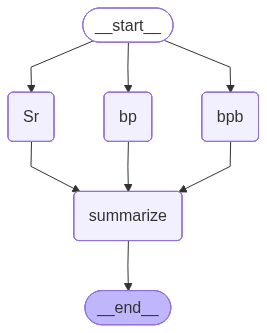

In [33]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())